## Import packages

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy import integrate

from ADFWI.model import IsotropicElasticModel
from ADFWI.propagator import ElasticPropagator
from ADFWI.survey import Receiver, SeismicData, Source, Survey
from ADFWI.utils import (
    get_smooth_marmousi_model,
    load_marmousi_model,
    numpy2tensor,
    resample_marmousi_model,
    wavelet,
)
from ADFWI.view import plot_bcx_bcz, plot_damp

project_path = "./examples/gradient_checking/Elastic-Marmousi2/data"
if not os.path.exists(os.path.join(project_path,"model")):
    os.makedirs(os.path.join(project_path,"model"))
if not os.path.exists(os.path.join(project_path,"waveform")):
    os.makedirs(os.path.join(project_path,"waveform"))
if not os.path.exists(os.path.join(project_path,"survey")):
    os.makedirs(os.path.join(project_path,"survey"))
if not os.path.exists(os.path.join(project_path,"inversion-AD")):
    os.makedirs(os.path.join(project_path,"inversion-AD"))


## Define the basic model parameter

In [2]:
device = "cuda:0"         # Specify the GPU device
dtype  = torch.float32     # Set data type to 32-bit floating point
ox, oz = 0, 0             # Origin coordinates for x and z directions
nz, nx = 50, 50          # Grid dimensions in z and x directions
dx, dz = 40, 40           # Grid spacing in x and z directions
nt, dt = 1600, 0.003      # Time steps and time interval
nabc = 30                 # Thickness of the absorbing boundary layer
f0 = 5                    # Initial frequency in Hz
free_surface = True       # Enable free surface boundary condition

## Define the initial velocity model

In [3]:
# Load the Marmousi model dataset from the specified directory.
marmousi_model = load_marmousi_model(in_dir="./examples/datasets/marmousi2_source")

# Create coordinate arrays for x and z based on the grid size.
x = np.linspace(7400, 7400+dx*nx, nx)
z = np.linspace(12*dz, (dz+12)*nz, nz)
true_model   = resample_marmousi_model(x, z, marmousi_model)
smooth_model = get_smooth_marmousi_model(true_model, gaussian_kernel=6,rcv_depth=0,mask_extra_detph=0)

# Initialize primary wave velocity (vp), Shear wave velocity (vs) and density (rho) for the model.
vp_init  = smooth_model['vp'].T
vs_init  = smooth_model['vs'].T
rho_init = smooth_model['rho'].T

# Extract true model properties for comparison.
vp_true = true_model['vp'].T 
vs_true = true_model['vs'].T 
rho_true = true_model['rho'].T 

# processing the water layer
model = IsotropicElasticModel(
                ox,oz,nx,nz,dx,dz,
                vp_init,vs_init,rho_init,
                vp_grad = True,vs_grad = True, rho_grad=True,
                auto_update_rho=False,auto_update_vp=False,
                free_surface=free_surface,
                abc_type="PML",abc_jerjan_alpha=0.007,nabc=nabc,
                device=device,dtype=dtype)

# Save the initialized model to a file for later use.
model.save(os.path.join(project_path, "model/init_model.npz"))

# Print the model's representation for verification.
print(model.__repr__())

model with parameters ['vp', 'vs', 'rho']:
  Model vp  :  1654.17 -  3266.16 m/s   , requires_grad = True, constrain bound: None - None
  Model vs  :   408.70 -  1658.52 m/s   , requires_grad = True, constrain bound: None - None
  Model rho :  1996.28 -  2313.58 kg/m^3, requires_grad = True, constrain bound: None - None
  Model orig: ox =   0.00, oz =   0.00 m
  Model grid: dx =  40.00, dz =  40.00 m
  Model dims: nx =     50, nz =     50
  Model size: 7500
  Free surface: True
  Absorbing layers: 30



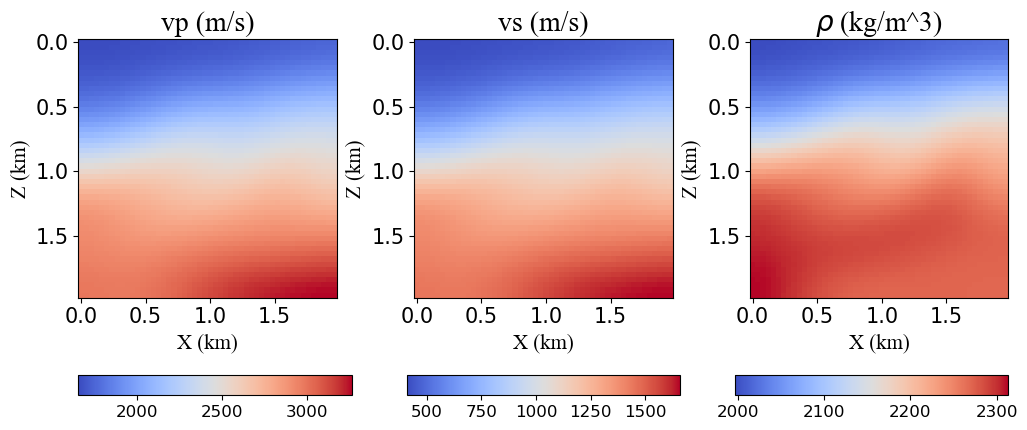

In [4]:
model._plot_vp_vs_rho(figsize=(12,5),wspace=0.3,cbar_pad_fraction=0.18,cbar_height=0.04,cmap='coolwarm',save_path=os.path.join(project_path,"model/init_vp_vs_rho.png"),show=True)

## Define the observed systems: Survey = Source + Receiver

In [5]:
# Define source positions in the model
src_z = np.array([45]) 
src_x = np.array([25])

# Generate wavelet for the source
src_t, src_v = wavelet(nt, dt, f0, amp0=1)  # Create time and wavelet amplitude
src_v = integrate.cumtrapz(src_v, axis=-1, initial=0)  # Integrate wavelet to get velocity

source = Source(nt=nt, dt=dt, f0=f0)  # Initialize source object

# Method 1: Add multiple sources at once (commented out)
# source.add_sources(src_x=src_x, src_z=src_z, src_wavelet=src_v, src_type='mt', src_mt=np.array([[1,0,0],[0,1,0],[0,0,1]]))

# Method 2: Loop through each source position to add them individually
for i in range(len(src_x)):
    source.add_source(src_x=src_x[i], src_z=src_z[i], src_wavelet=src_v, src_type="mt", src_mt=np.array([[1,0,0],[0,1,0],[0,0,1]]))


In [6]:
# Define receiver positions in the model
rcv_z = np.array([1  for i in range(0,nx,1)])
rcv_x = np.array([j  for j in range(0,nx,1)])

receiver = Receiver(nt=nt, dt=dt)  # Initialize receiver object

# Method 1: Add all receivers at once (commented out)
# receiver.add_receivers(rcv_x=rcv_x, rcv_z=rcv_z, rcv_type='pr')

# Method 2: Loop through each receiver position to add them individually
for i in range(len(rcv_x)):
    receiver.add_receiver(rcv_x=rcv_x[i], rcv_z=rcv_z[i], rcv_type="pr")

In [7]:
# Create a survey object using the defined source and receiver
survey = Survey(source=source, receiver=receiver)

# Print a representation of the survey object to check its configuration
print(survey.__repr__())

Survey Information:
Seismic Source:
  Source wavelet: 1600 samples at 3.00 ms
  Source number : 1
  Source types  : ['mt']
  Source x range: 25 - 25 (grids)
  Source z range: 45 - 45 (grids)

Seismic Receiver:
  Receiver data   : 1600 samples at 3.00 ms
  Receiver number : 50
  Receiver types  : ['pr']
  Receiver x range: 0 - 49 (grids)
  Receiver z range: 1 - 1 (grids)



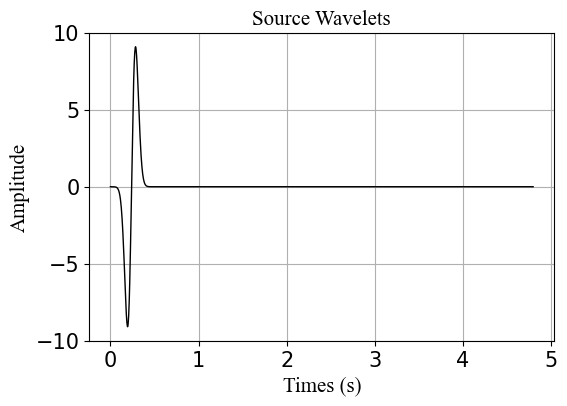

In [8]:
# Plot the wavelet used in the source
source.plot_wavelet(save_path=os.path.join(project_path, "survey/wavelets.png"))

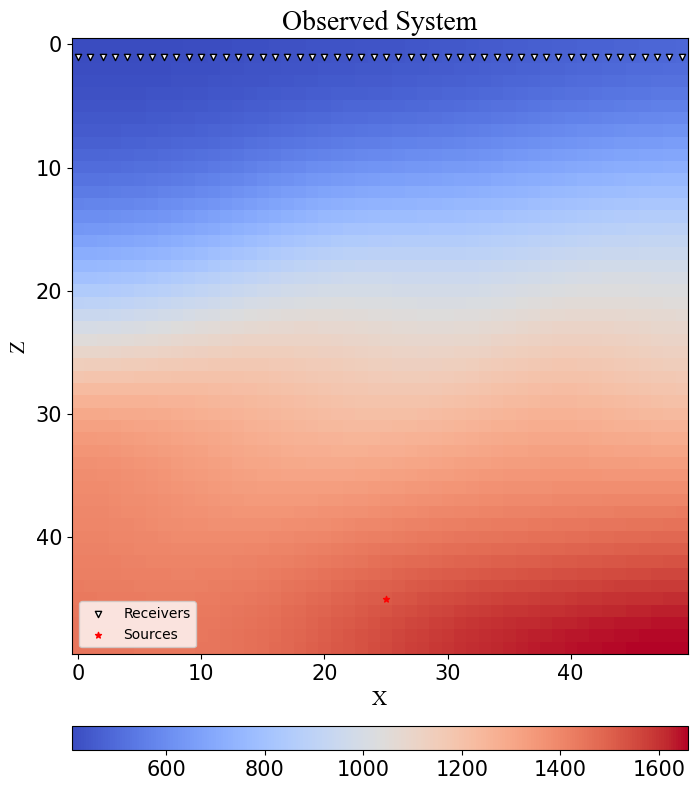

In [9]:
# Plot the survey configuration over the velocity model
survey.plot(model.vs,cmap='coolwarm',save_path=os.path.join(project_path,"survey/observed_system_init.png"))

## Define the propagator

In [10]:
# Initialize the wave propagator using the specified model and survey configuration
F = ElasticPropagator(model,survey,device=device)

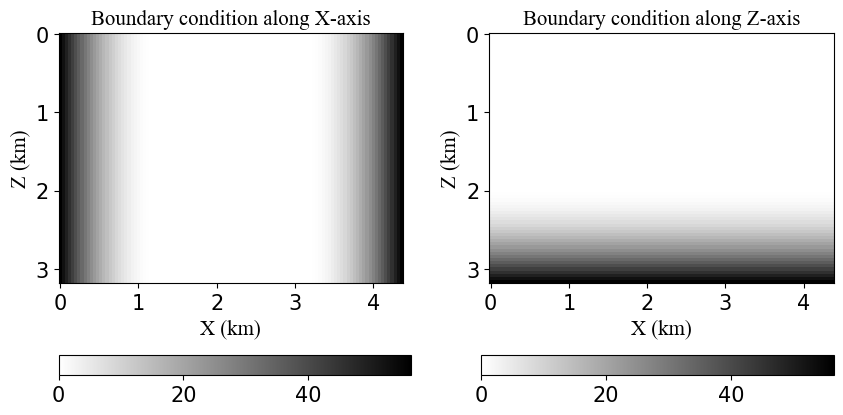

In [12]:
# Retrieve the damping array from the propagator and plot it to visualize boundary conditions
if model.abc_type == "PML":
    bcx = F.bcx
    bcz = F.bcz
    title_param = {'family':'Times New Roman','weight':'normal','size': 15}
    plot_bcx_bcz(bcx,bcz,dx=dx,dz=dz,wspace=0.25,title_param=title_param,cbar_height=0.04,cbar_pad_fraction=0.05,save_path=os.path.join(project_path,"model/boundary_condition_init.png"),show=True)
else:
    damp = F.damp
    plot_damp(damp)

## Load observed datasets

In [13]:
# load data
d_obs = SeismicData(survey)
d_obs.load(os.path.join(project_path,"waveform/obs_data.npz"))
print(d_obs.__repr__())

Seismic Data:
  Source number : 1
  Receiver number : 50
  Time samples : 1600 samples at 3.00 ms



## Synthetic

In [14]:
# Perform the forward propagation to record waveforms
record_waveform = F.forward(fd_order=4)

# Extract recorded pressure wavefield and particle velocities
rcv_txx = record_waveform["txx"]
rcv_tzz = record_waveform["tzz"]
rcv_txz = record_waveform["txz"]
rcv_vx  = record_waveform["vx"]
rcv_vz  = record_waveform["vz"]

# Extract forward wavefields for analysis
forward_wavefield_txx = record_waveform["forward_wavefield_txx"]
forward_wavefield_tzz = record_waveform["forward_wavefield_tzz"]
forward_wavefield_txz = record_waveform["forward_wavefield_txz"]
forward_wavefield_vx  = record_waveform["forward_wavefield_vx"]
forward_wavefield_vz  = record_waveform["forward_wavefield_vz"]

In [15]:
d_syn = SeismicData(survey)
d_syn.record_data(record_waveform)
d_syn.save(os.path.join(project_path,"waveform/syn_data.npz"))

## Gradient Calculate

In [16]:
rcv_p = -(rcv_txx+rcv_tzz)

In [17]:
rcv_syn_p = rcv_p
rcv_obs_p = numpy2tensor(-(d_obs.data["txx"]+d_obs.data["tzz"])).to(device)

normalize = False
if normalize:
    rcv_obs_p = rcv_obs_p/(torch.max(torch.abs(rcv_obs_p),axis=1,keepdim=True).values)
    rcv_syn_p = rcv_syn_p/(torch.max(torch.abs(rcv_syn_p),axis=1,keepdim=True).values)

loss = torch.sum((rcv_obs_p - rcv_syn_p)**2)
loss.backward()

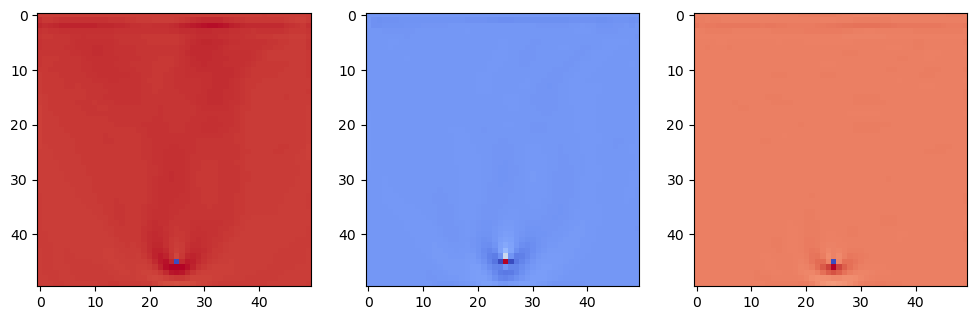

In [ ]:
grad_vp  = model.get_grad("vp")
grad_vs  = model.get_grad("vs")
grad_rho = model.get_grad("rho")

plt.figure(figsize=(12,4))
plt.subplot(131)
plt.imshow(grad_vp,cmap='coolwarm')
plt.subplot(132)
plt.imshow(grad_vs,cmap='coolwarm')
plt.subplot(133)
plt.imshow(grad_rho,cmap='coolwarm')
plt.show()

In [28]:
np.savez(os.path.join(project_path,"inversion-AD/grad_vp.npz"),data = grad_vp)
np.savez(os.path.join(project_path,"inversion-AD/grad_vs.npz"),data = grad_vs)
np.savez(os.path.join(project_path,"inversion-AD/grad_rho.npz"),data = grad_rho)